This notebook aims to find the optimal fitting between the AMOC index and the warming hole index.

20.326418241110392 4.375878251639118 -6.476941078546613 0.9802004267984377


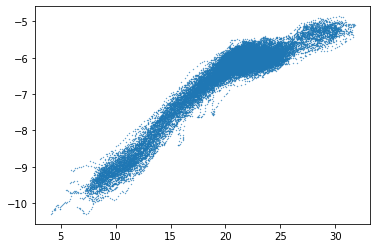

In [1]:
import numpy as np
import scipy as sp
import statsmodels.api as sm
from scipy.optimize import least_squares
import matplotlib.pyplot as plt 
import time

file_dir = '/Users/yifeifan/research/data/clean/' #'/Users/yifeifan/research/data/CESM-LE/'
pic_dir = '/Users/yifeifan/research/pic/'

# input data
model='CESM2'
x = np.loadtxt(file_dir+model+'_AMOC40_allexp_smooth_dump.txt')
y = np.loadtxt(file_dir+model+'_WHI_allexp_smooth_dump.txt')

## data preview 
plt.scatter(x,y,s=0.1)
print(x.mean(),x.std(),y.mean(),y.std())

In [2]:
print(len(x),np.max(x),np.min(x))

37579 31.79815101623535 4.070046424865723


# Four candidate fitting models

In [3]:
# psuedo input data 
xin = np.arange(2.5,34.1,0.1)
# mean sqaure errors of derived models
mse = {}
# fitted y values
y_fit = {}

## 1) One linear line 
Ordinary least square fitting.

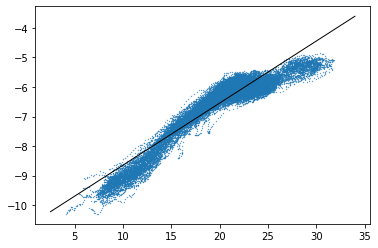

0.11602043837175834


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.879
Model:                            OLS   Adj. R-squared:                  0.879
Method:                 Least Squares   F-statistic:                 2.736e+05
Date:                Fri, 25 Oct 2024   Prob (F-statistic):               0.00
Time:                        13:55:28   Log-Likelihood:                -12850.
No. Observations:               37579   AIC:                         2.570e+04
Df Residuals:                   37577   BIC:                         2.572e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.7463      0.008  -1287.125      0.000     -10.763     -10.730
x1             0.2100      0.000    523.075      0.000       0.209       0.211
==============================================================================
Omnibus:                     1641.347   Durbin-Watson:                   0.025
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1843.144
Skew:                          -0.536   Prob(JB):                         0.00
Kurtosis:                       2.829   Cond. No.                         99.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [4]:
def MSE(y,y_pre):
    return np.mean((y-y_pre)**2,axis=0)
    
mod=sm.OLS(y,sm.add_constant(x)).fit()
fig, ax = plt.subplots(1,1)
plt.scatter(x,y,s=0.1)
plt.plot(xin,xin*mod.params[1]+mod.params[0],c='k',lw=1)
plt.show()

mse['OneLinear'] = MSE(y,x*mod.params[1]+mod.params[0])
print(mse['OneLinear'])
y_fit['OneLinear'] = x*mod.params[1]+mod.params[0]
mod.summary()

## 2) Logarithmic fit
$$y=a+b\ln x$$ 

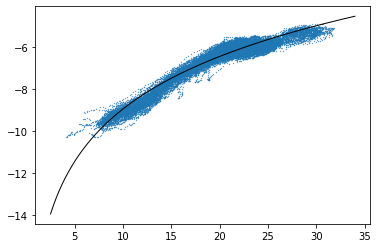

0.06773090618158246


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                 4.955e+05
Date:                Fri, 25 Oct 2024   Prob (F-statistic):               0.00
Time:                        13:55:43   Log-Likelihood:                -2737.0
No. Observations:               37579   AIC:                             5478.
Df Residuals:                   37577   BIC:                             5495.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -17.2628      0.015  -1122.286      0.000     -17.293     -17.233
x1             3.6167      0.005    703.896      0.000       3.607       3.627
==============================================================================
Omnibus:                      962.335   Durbin-Watson:                   0.031
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2061.641
Skew:                          -0.139   Prob(JB):                         0.00
Kurtosis:                       4.113   Cond. No.                         38.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [6]:
mod_log=sm.OLS(y,sm.add_constant(np.log(x))).fit()

fig, ax = plt.subplots(1,1)
plt.scatter(x,y,s=0.1)
plt.plot(xin,np.log(xin)*mod_log.params[1]+mod_log.params[0],c='k',lw=1)
plt.show()

mse['Log'] = MSE(y,np.log(x)*mod_log.params[1]+mod_log.params[0])
y_fit['Log'] = np.log(x)*mod_log.params[1]+mod_log.params[0]
print(mse['Log'])
mod_log.summary()

In [7]:
from random import choices

##  Set paramters of the genetic algorithm
# Number of individuals/populations 
N = 1000

# Max Generations
maxG = 100

# Elite Count; elite individuals are passed directly to the next population
elite_frac = 0.1
elite_num = int(elite_frac*N)

# Crossover Fraction, the fraction of the population, other than elite children, that are crossover children
co_frac = 0.5
co_num = int(co_frac*(N-elite_num)) # Crossover Count

# Mutation Count
mutation_num = N-elite_num-co_num

# Tolerance
#tolerance = 1e-10

# Stop the algorithm when the best individual of one generation stays the same for x generations 
same_count = 10

# define a funtion to calculate the predicted value of y, given the parameters 
def preY(x,params):
    # x: input data 
    # params: a list of parameters; [a,b1,b2,xc] or [a,b1,b2,b3,xc1,xc2]
    
    # create a new array to storage predicted y values given a set of parameters 
    y_pre = np.zeros((len(x),len(params[0])))

    # Two linear lines 
    if (len(params)==4):
        a,b1,b2,xc = params
        for i in range(len(a)):
            y_pre[:,i] = np.where(x<xc[i],a[i]+b1[i]*x,a[i]+b1[i]*xc[i]+b2[i]*(x-xc[i]))
        return y_pre
    # Three linear lines
    elif (len(params)==6):
        a,b1,b2,b3,xc1,xc2 = params
        for i in range(len(a)):
            y_pre[:,i] = np.where(x<xc1[i],a[i]+b1[i]*x,a[i]+b1[i]*xc1[i]+b2[i]*(x-xc1[i]))
            y_pre[:,i] = np.where(x>=xc2[i],a[i]+b1[i]*xc1[i]+b2[i]*(xc2[i]-xc1[i])+b3[i]*(x-xc2[i]),y_pre[:,i])
        return y_pre
    elif (len(params)==8):
        a,b1,b2,b3,b4 = params[:5,:]
        xc1,xc2,xc3 = np.sort(params[5:,:],axis=0)
        for i in range(len(a)):
            y_pre[:,i] = np.where(x<xc1[i],a[i]+b1[i]*x,a[i]+b1[i]*xc1[i]+b2[i]*(x-xc1[i]))
            y_pre[:,i] = np.where((x>=xc2[i])&(x<xc3[i]),a[i]+b1[i]*xc1[i]+b2[i]*(xc2[i]-xc1[i])+b3[i]*(x-xc2[i]),y_pre[:,i])
            y_pre[:,i] = np.where((x>=xc3[i]),a[i]+b1[i]*xc1[i]+b2[i]*(xc2[i]-xc1[i])+b3[i]*(xc3[i]-xc2[i])+b4[i]*(x-xc3[i]),y_pre[:,i])
        return y_pre
    elif (len(params)==10):
        a,b1,b2,b3,b4,b5 = params[:6,:]
        xc1,xc2,xc3,xc4 = np.sort(params[6:,:],axis=0)
        for i in range(len(a)):
            y_pre[:,i] = np.where(x<xc1[i],a[i]+b1[i]*x,a[i]+b1[i]*xc1[i]+b2[i]*(x-xc1[i]))
            y_pre[:,i] = np.where((x>=xc2[i])&(x<xc3[i]),a[i]+b1[i]*xc1[i]+b2[i]*(xc2[i]-xc1[i])+b3[i]*(x-xc2[i]),y_pre[:,i])
            y_pre[:,i] = np.where((x>=xc3[i])&(x<xc4[i]),a[i]+b1[i]*xc1[i]+b2[i]*(xc2[i]-xc1[i])+b3[i]*(xc3[i]-xc2[i])+b4[i]*(x-xc3[i]),y_pre[:,i])
            y_pre[:,i] = np.where((x>=xc4[i]),a[i]+b1[i]*xc1[i]+b2[i]*(xc2[i]-xc1[i])+b3[i]*(xc3[i]-xc2[i])+b4[i]*(xc4[i]-xc3[i])+b5[i]*(x-xc4[i]),y_pre[:,i])
        return y_pre        

    else: 
        print('Wrong number of parameters!')
        
def LinearFit(x,params):
    # Two linear lines 
    if (len(params)==4):
        a,b1,b2,xc = params
        return np.where(x<xc,a+b1*x,a+b1*xc+b2*(x-xc))
    # Three linear lines
    elif (len(params)==6):
        a,b1,b2,b3,xc1,xc2 = params
        y_pre = np.where(x<xc1,a+b1*x,a+b1*xc1+b2*(x-xc1))
        return np.where(x>=xc2,a+b1*xc1+b2*(xc2-xc1)+b3*(x-xc2),y_pre)
    elif (len(params)==8):
        a,b1,b2,b3,b4 = params[:5]
        xc1,xc2,xc3 = np.sort(params[5:])
        y_pre = np.where(x<xc1,a+b1*x,a+b1*xc1+b2*(x-xc1))
        y_pre = np.where((x>=xc2)&(x<xc3),a+b1*xc1+b2*(xc2-xc1)+b3*(x-xc2),y_pre)
        return np.where(x>=xc3,a+b1*xc1+b2*(xc2-xc1)+b3*(xc3-xc2)+b4*(x-xc3),y_pre) 
    elif (len(params)==10):
        a,b1,b2,b3,b4,b5 = params[:6]
        xc1,xc2,xc3,xc4 = np.sort(params[6:])
        y_pre = np.where(x<xc1,a+b1*x,a+b1*xc1+b2*(x-xc1))
        y_pre = np.where((x>=xc2)&(x<xc3),a+b1*xc1+b2*(xc2-xc1)+b3*(x-xc2),y_pre)
        y_pre = np.where((x>=xc3)&(x<xc4),a+b1*xc1+b2*(xc2-xc1)+b3*(xc3-xc2)+b4*(x-xc3),y_pre)           
        return np.where(x>=xc4,a+b1*xc1+b2*(xc2-xc1)+b3*(xc3-xc2)+b4*(xc4-xc3)+b5*(x-xc4),y_pre) 
    else:
        print('Something wrong!')


def find_ols_params(x,y,cps):
    # cps: Change PointS [:,:]
    # one change point:
    
    # number of individuals 
    N = cps.shape[1]
    
    # number of change points 
    nc = cps.shape[0]
    
    params = np.zeros((nc*2+2,N))
    
    for i in range(N):
        if (nc==1):
            # Use OLS fitting to find the best fit in the first regime
            xc = cps[0,i]
            x_temp1 = x[np.where(x<=xc)[0]]
            y_temp1 = y[np.where(x<=xc)[0]]
            mod=sm.OLS(y_temp1,sm.add_constant(x_temp1)).fit()
            b0,b1 = mod.params[:]
            y_xc = xc*b1+b0 
        
            # Use an optimizing function to find the best fit in the second regime
            # the best fit line must go through the point (xc,y_xc) while it minimizes the SSE
            x_temp2 = x[np.where(x>xc)[0]]-xc   # so that y_pre = k*x
            y_temp2 = y[np.where(x>xc)[0]]-y_xc # so that y_pre = k*x
            # sum of squared error, given y_pre = k*x
            # used for optimizting unknown parameter k 
            def SSE(k,x=x_temp2,y=y_temp2):
                # k: unknown value of the slope 
                # x, y: known x and y (np.array)
                return np.sum((k*x-y)**2)
            b2 = least_squares(SSE,x0=np.array([0.2])).x
            params[:,i] = np.array([b0,b1,b2,xc])
            
        elif(nc==2):
            # Use OLS fitting to find the best fit in the second (middle) regime
            xc1,xc2 = np.sort(cps[:,i])
            x_temp = x[np.where((x>xc1)&(x<=xc2))[0]]
            y_temp = y[np.where((x>xc1)&(x<=xc2))[0]]
            mod=sm.OLS(y_temp,sm.add_constant(x_temp)).fit()
            b2 = mod.params[1] # slope of the second regime 
            y_xc1 = xc1*b2+mod.params[0] 
            y_xc2 = xc2*b2+mod.params[0] 
            
            x_temp1 = x[np.where(x<=xc1)[0]]-xc1
            y_temp1 = y[np.where(x<=xc1)[0]]-y_xc1
            def SSE(k,x=x_temp1,y=y_temp1):
                return np.sum((k*x-y)**2)
            b1 = least_squares(SSE,x0=np.array([0.2])).x
            b0 = y_xc1-b1*xc1
            
            x_temp2 = x[np.where(x>xc2)[0]]-xc2
            y_temp2 = y[np.where(x>xc2)[0]]-y_xc2
            def SSE(k,x=x_temp2,y=y_temp2):
                return np.sum((k*x-y)**2)
            b3 = least_squares(SSE,x0=np.array([0.2])).x
                        
            params[:,i] = np.array([b0,b1,b2,b3,xc1,xc2])
            
        elif(nc==3):
            xc1,xc2,xc3 = np.sort(cps[:,i])
            x_temp = x[np.where((x>xc1)&(x<=xc2))[0]]
            y_temp = y[np.where((x>xc1)&(x<=xc2))[0]]
            mod=sm.OLS(y_temp,sm.add_constant(x_temp)).fit()
            b2 = mod.params[1] # slope of the second regime 
            y_xc1 = xc1*b2+mod.params[0] 
            y_xc2 = xc2*b2+mod.params[0] 
            
            x_temp1 = x[np.where(x<=xc1)[0]]-xc1
            y_temp1 = y[np.where(x<=xc1)[0]]-y_xc1
            def SSE(k,x=x_temp1,y=y_temp1):
                return np.sum((k*x-y)**2)
            b1 = least_squares(SSE,x0=np.array([0.2])).x
            b0 = y_xc1-b1*xc1
            
            x_temp2 = x[np.where((x>xc2)&(x<=xc3))[0]]-xc2
            y_temp2 = y[np.where((x>xc2)&(x<=xc3))[0]]-y_xc2
            def SSE(k,x=x_temp2,y=y_temp2):
                return np.sum((k*x-y)**2)
            b3 = least_squares(SSE,x0=np.array([0.2])).x
            y_xc3 = (xc3-xc2)*b3+y_xc2
            
            x_temp3 = x[np.where(x>xc3)[0]]-xc3
            y_temp3 = y[np.where(x>xc3)[0]]-y_xc3
            def SSE(k,x=x_temp3,y=y_temp3):
                return np.sum((k*x-y)**2)
            b4 = least_squares(SSE,x0=np.array([0.2])).x
            
            params[:,i] = np.array([b0,b1,b2,b3,b4,xc1,xc2,xc3])
        elif(nc==4):
            xc1,xc2,xc3,xc4 = np.sort(cps[:,i])
            x_temp = x[np.where((x>xc1)&(x<=xc2))[0]]
            y_temp = y[np.where((x>xc1)&(x<=xc2))[0]]
            mod=sm.OLS(y_temp,sm.add_constant(x_temp)).fit()
            b2 = mod.params[1] # slope of the second regime 
            y_xc1 = xc1*b2+mod.params[0] 
            y_xc2 = xc2*b2+mod.params[0] 
            
            x_temp1 = x[np.where(x<=xc1)[0]]-xc1
            y_temp1 = y[np.where(x<=xc1)[0]]-y_xc1
            def SSE(k,x=x_temp1,y=y_temp1):
                return np.sum((k*x-y)**2)
            b1 = least_squares(SSE,x0=np.array([0.2])).x
            b0 = y_xc1-b1*xc1
            
            x_temp2 = x[np.where((x>xc2)&(x<=xc3))[0]]-xc2
            y_temp2 = y[np.where((x>xc2)&(x<=xc3))[0]]-y_xc2
            def SSE(k,x=x_temp2,y=y_temp2):
                return np.sum((k*x-y)**2)
            b3 = least_squares(SSE,x0=np.array([0.2])).x
            y_xc3 = (xc3-xc2)*b3+y_xc2

            x_temp3 = x[np.where((x>xc3)&(x<=xc4))[0]]-xc3
            y_temp3 = y[np.where((x>xc3)&(x<=xc4))[0]]-y_xc3
            def SSE(k,x=x_temp3,y=y_temp3):
                return np.sum((k*x-y)**2)
            b4 = least_squares(SSE,x0=np.array([0.2])).x
            y_xc4 = (xc4-xc3)*b4+y_xc3
            
            x_temp4 = x[np.where(x>xc4)[0]]-xc4
            y_temp4 = y[np.where(x>xc4)[0]]-y_xc4
            def SSE(k,x=x_temp4,y=y_temp4):
                return np.sum((k*x-y)**2)
            b5 = least_squares(SSE,x0=np.array([0.2])).x
            
            params[:,i] = np.array([b0,b1,b2,b3,b4,b5,xc1,xc2,xc3,xc4])
        else:
            params[:,i] = np.nan
    #print(params[-1,:])
    return params
    
    
### Step 2. Create next generations and find the fittest individual 
"""
def gene(x,y,param0,N=N,maxG=maxG,elite_num=elite_num,co_num=co_num,mutation_num=mutation_num,same_count=same_count):
    # return:
    #        1) the final best estimate of the parameters 
    #        2) the best estimate of the parameters at each generation
    
    # number of parameters 
    nparam = param0.shape[0]
    
    # create a array to storage the performance of the "best" individual at each generation 
    mse_best = np.zeros(maxG)
    mse_best[:] = np.nan
    
    # create a array to storage the "best" individual at each generation 
    para_best = []
    
    for i in range(maxG):
        print(i)
        ## 2.1 Evaluate the performance of the current population
        # predicted values using the initial combination of the four parameters 
        y_pre0 = preY(x,param0)

        # performance score, estimated by mean squared error
        Y = np.asarray(np.asmatrix(y).T*np.asmatrix(np.ones(N))) 
        mse0 = MSE(Y,y_pre0)
        
        # reorder the individuals by its mes
        param0_reorder = param0[:,np.argsort(mse0)] # [best, ..., worst]
        
        ## 2.2 Create the next generation 
        # 2.2.1 Select elite children, that is, the elite_num sets of parameters giving the lowest MSE
        param0[:,:elite_num] = param0_reorder[:,:elite_num]
        para_best.append(param0_reorder[:,0])
        mse_best[i] = np.min(mse0)
        print(mse_best[i])

        # 2.2.2 Create crossover children
        np.random.seed(3)
        
        # 2.2.2.1 Select mom and dad 
        weights = np.arange(N,0,-1)/np.sum(np.arange(1,N+1))
        mom_idx = choices(population=np.arange(0,N,1), weights=weights,k=int(co_num/2))
        dad_idx = choices(population=np.arange(0,N,1), weights=weights,k=int(co_num/2))
        
        # if the mom and dad are identical, re-select dad 
        same_dad_mom_idx = np.where(np.asarray(dad_idx)==np.asarray(mom_idx))[0]
        if (len(same_dad_mom_idx)!=0):
            for idx in same_dad_mom_idx:
                print(idx)
                # the chance of selecting the same individual again is quite small 
                dad_idx[idx] = choices(population=np.arange(0,N,1), weights=weights,k=1)
    
        # 2.2.2.2 Select crossover point
        co_pt = np.random.randint(low=0, high=nparam-1,size=int(co_num/2))
        
        # 2.2.2.3 Combine genes to create children 
        # for each pair of parents 
        for k in range(int(co_num/2)):
            # first child
            param0[:,elite_num+2*k]=np.append(param0_reorder[:co_pt[k],mom_idx[k]],param0_reorder[co_pt[k]:,dad_idx[k]])
            # second child 
            param0[:,elite_num+2*k+1]=np.append(param0_reorder[co_pt[k]:,mom_idx[k]],param0_reorder[:co_pt[k],dad_idx[k]])
            
        # 2.2.3 Create mutation children 
        # select individuals to perturb 
        mutation_index = np.random.randint(low=0, high=N-1,size=mutation_num)
        # adds a random vector from a normal distribution
        for pi in range(nparam):
            perturb = 0.01*abs(np.mean(param0[pi,:]))
            param0[pi,-mutation_num:] = param0_reorder[pi,mutation_index] + np.random.normal(0,perturb,[mutation_num])
        
        ## 2.3 Stop condition 
        if (i>same_count):
            if (mse_best[i-same_count:i+1].min()==mse_best[i-same_count:i+1].max()):
                return para_best
    return para_best

"""
def gene(x,y,cps0,N=N,maxG=maxG,elite_num=elite_num,co_num=co_num,mutation_num=mutation_num,same_count=same_count):
    # x, y: input x and y
    # cps0: initial guess of change points 
    # return:
    #        1) the final best estimate of the parameters 
    #        2) the best estimate of the parameters at each generation
    
    # number of change points  
    nc = cps0.shape[0]
    nparam = nc*2+2
    # create a array to storage the performance of the "best" individual at each generation 
    mse_best = np.zeros(maxG)
    mse_best[:] = np.nan
    
    # create a array to storage the "best" individual at each generation 
    para_best = []
    
    for i in range(maxG):
        print(i)
        ## 2.1 Evaluate the performance of the current population
        # predicted values using the initial combination of the four parameters 
        param0 = find_ols_params(x,y,cps0)
        y_pre0 = preY(x,param0)

        # performance score, estimated by mean squared error
        Y = np.asarray(np.asmatrix(y).T*np.asmatrix(np.ones(N))) 
        mse0 = MSE(Y,y_pre0)
        
        # reorder the individuals by its mes
        param0_reorder = param0[:,np.argsort(mse0)] # [best, ..., worst]
        
        ## 2.2 Create the next generation 
        # 2.2.1 Select elite children, that is, the elite_num sets of parameters giving the lowest MSE
        param0[:,:elite_num] = param0_reorder[:,:elite_num]
        para_best.append(param0_reorder[:,0])
        mse_best[i] = np.min(mse0)
        print(mse_best[i])
        # 2.2.2 Create crossover children
        np.random.seed(3)
        
        # 2.2.2.1 Select mom and dad 
        weights = np.arange(N,0,-1)/np.sum(np.arange(1,N+1))
        mom_idx = choices(population=np.arange(0,N,1), weights=weights,k=int(co_num/2))
        dad_idx = choices(population=np.arange(0,N,1), weights=weights,k=int(co_num/2))
        
        # if the mom and dad are identical, re-select dad 
        same_dad_mom_idx = np.where(np.asarray(dad_idx)==np.asarray(mom_idx))[0]
        if (len(same_dad_mom_idx)!=0):
            for idx in same_dad_mom_idx:
                print(idx)
                # the chance of selecting the same individual again is quite small 
                dad_idx[idx] = choices(population=np.arange(0,N,1), weights=weights,k=1)
    
        # 2.2.2.2 Select crossover point
        co_pt = np.random.randint(low=1, high=nparam-1,size=int(co_num/2))
        
        # 2.2.2.3 Combine genes to create children 
        # for each pair of parents 
        for k in range(int(co_num/2)):
            # first child
            param0[:,elite_num+2*k]=np.append(param0_reorder[:co_pt[k],mom_idx[k]],param0_reorder[co_pt[k]:,dad_idx[k]])
            # second child 
            param0[:,elite_num+2*k+1]=np.append(param0_reorder[:co_pt[k],dad_idx[k]],param0_reorder[co_pt[k]:,mom_idx[k]])

        # 2.2.3 Create mutation children 
        # select individuals to perturb 
        mutation_index = np.random.randint(low=0, high=N-1,size=mutation_num)
        # adds a random vector (0.05) from a normal distribution
        param0[-nc:,-mutation_num:] = param0_reorder[-nc:,mutation_index] + np.ones((nc,mutation_num))/20
        
        cps0 = param0[nparam-nc:,:]
        
        ## 2.3 Stop condition 
        if (i>same_count):
            if (mse_best[i-same_count:i+1].min()==mse_best[i-same_count:i+1].max()):
                return para_best
    return para_best

## 3) Two linear lines
Four parameters are to be estimated: the slope of the lines, $b_1$ and $b_2$; the intercept $a$; and the critical point $x_c$. 
$$y=a+b_1x, x<x_c \\ y=a_2+b_2x=a+b_1x_c+b_2(x-x_c), x>=x_c$$

We use a **genetic algorithm** to find the optimal combination of the four parameters. To create the intial population of the four parameters, we make the following assumption based on previous OLS regression. 
1. 15<$x_c$<30

In [8]:
### Step 1. Create initial population 
start_time = time.time()

# generate the same random numbers everytime we run the code
np.random.seed(3)

# initial change points [e.g., 12.12, 21.35, 16.84, ...]
cps0 = np.asarray([np.random.randint(low=500, high=3000,size=N)/100])
temp1 = gene(x,y,cps0)[:]
best1 = temp1[-1]
print(best1)
mse['TwoLinear_N='+str(N)+'_EliteFrac='+str(elite_frac)+'_CrossOverFrac='+str(co_frac)] = MSE(y,LinearFit(x,best1))
print(mse['TwoLinear_N='+str(N)+'_EliteFrac='+str(elite_frac)+'_CrossOverFrac='+str(co_frac)])

end_time = time.time()
elapsed_time = (end_time - start_time)
print(f"Elapsed time: {elapsed_time:.4f} seconds")

0


/Users/yifeifan/opt/anaconda3/envs/xesmf/lib/python3.7/site-packages/ipykernel_launcher.py:129: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.


0.04177583097451109
1
0.04177583097451109
143
2
0.04177583097451109
3
0.04177583097451109
4
0.04177071150249198
5
0.04177071150249198
6
0.04177071150249198
7
0.04177071150249198
36
161
8
0.04177071150249198
9
0.04177071150249198
194
10
0.04177071150249198
104
11
0.04177071150249198
12
0.04177071150249198
13
0.04177071150249198
28
14
0.04177071150249198
11
[-11.91996637   0.285457     0.08547464  20.        ]
0.04177071150249209
Elapsed time: 117.0538 seconds


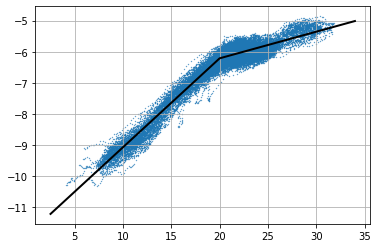

In [9]:
y_fit['TwoLinear'] = LinearFit(x,best1)
plt.scatter(x,y,s=0.1)
plt.grid()
plt.plot(xin,LinearFit(xin,best1),lw=2,c='k')

## 4) Three linear lines
Six parameters are to be estimated: the slope of the lines, $b_1$, $b_2$, and $b_3$; the intercept $a$; and the critical point $x_c1$ and $x_c2$ ($x_c1$<$x_c2$). 
$$y=a+b_1x, x<x_{c1} \\ y=a+b_1x_{c1}+b_2(x-x_{c1}), x_{c1}=<x<x_{c2} \\ y=a+b_1x_{c1}+b_2(x_{c2}-x_{c1})+b_3(x-x_{c2}), x>=x_{c2}$$

To create the intial population of the four parameters, we make the following assumption based on previous OLS regression. 
1. 5<$x_{c1}$<15
2. 15<$x_{c2}$<30

In [10]:
start_time = time.time()
N=1000
np.random.seed(1)

cps0 = np.asarray([np.random.randint(low=500, high=1500,size=N)/100,
                  np.random.randint(low=1500, high=3000,size=N)/100])

temp2 = gene(x,y,cps0)[:]
best2 = temp2[-1]
print(best2)
mse['ThreeLinear_N='+str(N)+'_EliteFrac='+str(elite_frac)+'_CrossOverFrac='+str(co_frac)] = MSE(y,LinearFit(x,best2))
print(mse['ThreeLinear_N='+str(N)+'_EliteFrac='+str(elite_frac)+'_CrossOverFrac='+str(co_frac)])

end_time = time.time()
elapsed_time = (end_time - start_time)
print(f"Elapsed time: {elapsed_time:.4f} seconds")

0


/Users/yifeifan/opt/anaconda3/envs/xesmf/lib/python3.7/site-packages/ipykernel_launcher.py:154: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.


0.04075480402690009
1
0.04075480402690009
2
0.04075480402690009
3
0.04075480402690009
4
0.04075480402690009
5
0.04074102367863075
6
0.040725365071249714
7
0.040725365071249714
8
0.040725365071249714
9
0.040713206179834496
10
0.040713206179834496
11
0.040713206179834496
24
12
0.040713206179834496
13
0.04070780521035873
14
0.04070780521035873
15
0.04070780521035873
16
0.04070780521035873
17
0.04070780521035873
10
18
0.04070780521035873
19
0.04070780521035873
20
0.04070780521035873
21
0.04070780521035873
22
0.04070780521035873
5
23
0.04070780521035873
[-10.97261616   0.18763409   0.29960627   0.08677885  10.6
  19.77      ]
0.04070780521035886
Elapsed time: 242.7345 seconds


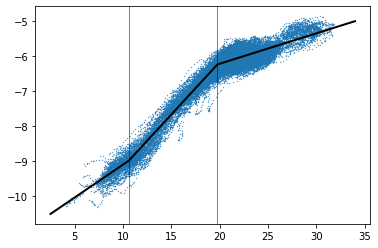

In [11]:
y_fit['ThreeLinear'] = LinearFit(x,best2)
plt.scatter(x,y,s=0.1)
plt.plot(xin,LinearFit(xin,best2),lw=2,c='k')
plt.axvline(x=best2[-2],lw=0.5,c='k')
plt.axvline(x=best2[-1],lw=0.5,c='k')

## 4) Three change points
Eight parameters are to be estimated: the slope of the lines, $b_1$, $b_2$, and $b_3$; the intercept $a$; and the critical point $x_c1$ and $x_c2$ ($x_c1$<$x_c2$). 
$$y=a+b_1x, x<x_{c1} \\ y=a+b_1x_{c1}+b_2(x-x_{c1}), x_{c1}=<x<x_{c2} \\ y=a+b_1x_{c1}+b_2(x_{c2}-x_{c1})+b_3(x-x_{c2}), x_{c2}x<x_{c3} \\ y=a+b_1x_{c1}+b_2(x_{c2}-x_{c1})+b_3(x_{c3}-x_{c2})+b_4(x-x_{c3}), x>x_{c3}$$

To create the intial population of the four parameters, we make the following assumption based on previous OLS regression. 
1. 10<$x_{c1}$<13
2. 19<$x_{c2}$<21
3. 21<$x_{c2}$<30

In [9]:
start_time = time.time()
np.random.seed(1)
N=1000

cps0 = np.asarray([np.random.randint(low=1000, high=1300,size=N)/100,
                  np.random.randint(low=1900, high=2100,size=N)/100,
                  np.random.randint(low=2101, high=3000,size=N)/100])

temp3 = gene(x,y,cps0)[:]
best3 = temp3[-1]
print(best3)

0


/Users/yifeifan/opt/anaconda3/envs/xesmf/lib/python3.7/site-packages/ipykernel_launcher.py:168: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.


0.04851500522578441
105
1
0.04851500522578441
42
2
0.04851500522578441
3
0.04850997927418644
4
0.04850997927418644
4
71
5
0.04850997927418644
6
0.04850997927418644
7
0.04850997927418644
8
0.04850938777270776
9
0.04850402671473731
116
10
0.04850336683395459
11
0.04850336683395459
12
0.04850282266369616
13
0.04850220905595872
14
0.04850220905595872
15
0.04850220905595872
16
0.04850220905595872
17
0.04850220905595872
18
0.04850220905595872
19
0.04850220905595872
20
0.04850220905595872
21
0.04850220905595872
22
0.04850220905595872
23
0.04850220905595872
[-11.45473471   0.12327772   0.30497102   0.06953438   0.13451362
  11.5         20.19        24.89      ]


In [10]:
mse['FourLinear_N='+str(N)+'_EliteFrac='+str(elite_frac)+'_CrossOverFrac='+str(co_frac)] = MSE(y,LinearFit(x,best3))
print(mse['FourLinear_N='+str(N)+'_EliteFrac='+str(elite_frac)+'_CrossOverFrac='+str(co_frac)])

end_time = time.time()
elapsed_time = (end_time - start_time)
print(f"Elapsed time: {elapsed_time:.4f} seconds")

0.04850220905595865
Elapsed time: 766.5535 seconds


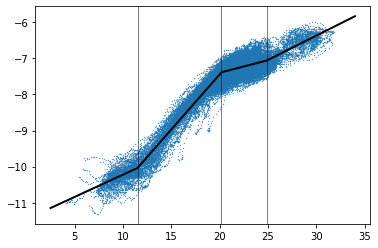

In [11]:
y_fit['FourLinear'] = LinearFit(x,best3)
plt.scatter(x,y,s=0.1)
plt.plot(xin,LinearFit(xin,best3),lw=2,c='k')
plt.axvline(x=best3[-3],lw=0.5,c='k')
plt.axvline(x=best3[-2],lw=0.5,c='k')
plt.axvline(x=best3[-1],lw=0.5,c='k')

## 4) Four change points
To create the intial population of the four parameters, we make the following assumption based on previous OLS regression. 
1. 5<$x_{c1}$<10
2. 10<$x_{c1}$<13
3. 19<$x_{c2}$<21
4. 21<$x_{c2}$<30

In [28]:
start_time = time.time()
np.random.seed(1)
N=1000
cps0 = np.asarray([np.random.randint(low=500, high=1000,size=N)/100,
                   np.random.randint(low=1000, high=1300,size=N)/100,
                   np.random.randint(low=1900, high=2100,size=N)/100,
                   np.random.randint(low=2101, high=3000,size=N)/100])

temp4 = gene(x,y,cps0)[:]
best4 = temp4[-1]
print(best4)

0


/Users/yifeifan/opt/anaconda3/envs/xesmf/lib/python3.7/site-packages/ipykernel_launcher.py:222: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.


0.048592543190312414
1
0.04851197867675943
2
0.04851197867675943
3
0.04851197867675943
63
4
0.04851197867675943
41
5
0.04851197867675943
6
0.04851197867675943
219
7
0.04850638576536663
8
0.048498995600665486
9
0.048498995600665486
160
10
0.048498995600665486
11
0.048498995600665486
89
189
12
0.04849884192740434
13
0.04849884192740434
167
14
0.04849680826637098
15
0.04849680826637098
16
0.04849680826637098
17
0.04849680826637098
18
0.04849629566389678
53
88
19
0.04849629566389678
20
0.04849623290598617
21
0.04849623290598617
22
0.04849623290598617
23
0.04849623290598617
60
84
24
0.04849623290598617
25
0.04849623290598617
26
0.04849623290598617
27
0.04849558190412698
30
125
28
0.04849558190412698
29
0.04849558190412698
178
30
0.04849558190412698
31
0.04849558190412698
32
0.04849557753451796
33
0.04849557753451796
34
0.04849557753451796
199
35
0.048495495030507714
18
36
0.048495495030507714
37
0.048495495030507714
133
38
0.048495495030507714
99
39
0.048495495030507714
41
40
0.048495495030

0.04850220905595865
Elapsed time: 710.8185 seconds


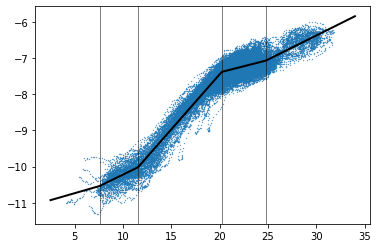

In [29]:
mse['FiveLinear_N='+str(N)+'_EliteFrac='+str(elite_frac)+'_CrossOverFrac='+str(co_frac)] = MSE(y,LinearFit(x,best3))
print(mse['FiveLinear_N='+str(N)+'_EliteFrac='+str(elite_frac)+'_CrossOverFrac='+str(co_frac)])

end_time = time.time()
elapsed_time = (end_time - start_time)
print(f"Elapsed time: {elapsed_time:.4f} seconds")

y_fit['FiveLinear'] = LinearFit(x,best4)
plt.scatter(x,y,s=0.1)
plt.plot(xin,LinearFit(xin,best4),lw=2,c='k')
plt.axvline(x=best4[-4],lw=0.5,c='k')
plt.axvline(x=best4[-3],lw=0.5,c='k')
plt.axvline(x=best4[-2],lw=0.5,c='k')
plt.axvline(x=best4[-1],lw=0.5,c='k')

# Model selection 
Select the best model using the penalized likelihood method. Likelihood methods choose the model parameters that make seeing the observed data most likely, while a penalty (P) is imposed on the model to keep it from having too many parameters (overfitting):

$$-2ln[L(p;a1,...,ap)]+P(p;a1,...,ap)$$

where L(p;a1,...,ap) is the optimal Gaussian likelihood that can be achieved from a model with p parameters (a1,...,ap). 

$$ lnL(\mu,\sigma^2) = -\frac{1}{2\sigma^2}\sum_{i=1}^{N}(lnX_i-\mu)^2 - Nln(\sigma \sqrt{2\pi})-ln(\prod_{i=1}^{N} X_i) $$

Using Bayesian information criterion, $P=p\cdot ln(N)$. We compare BIC statistics for all fitted models and choose the one with the lowest BIC score. 


In [30]:
def GL(y,y_pre,p):
    # obs: observed values (given a fitting model)
    # return the Gaussian likelihood
    # sigma: estimated white noise variance 
    
    N=len(y)
    var = (y_pre-y).var()
    # log-likelihood
    #likelihood = -2*(-N/2*(np.log(2*np.pi)+np.log(sigma**2))-np.sum((y_pre-y)**2)/(2*sigma**2))
    term1 = np.log10(2*np.pi)
    term2 = np.log10(var)
    likelihood = (term1+term2+1)*N
    print(var,term1,term2,likelihood)
    return likelihood

N_data = len(x)
p = {}
p['OneLinear'] = 2
p['Log'] = 2
p['TwoLinear'] = 4
p['ThreeLinear'] = 6
p['FourLinear'] = 8
p['FiveLinear'] = 10

BIC = {}
for key in ['OneLinear','Log','TwoLinear','ThreeLinear','FourLinear','FiveLinear']:
    BIC[key] = (GL(y,y_fit[key],p[key]))+p[key]*np.log(N_data)
BIC

0.11272473335128592 0.798179868358115 -0.947980783337445 33952.70046030046
0.08039238414492296 0.798179868358115 -1.094785091556234 28090.070411583118
0.054075338550176884 0.798179868358115 -1.267000752887236 21212.637976329555
0.04935203000478022 0.798179868358115 -1.3066949787239872 19627.449067538895
0.0485021278636631 0.798179868358115 -1.314239207806488 19326.17027912923
0.04849399629787431 0.798179868358115 -1.3143120250286213 19323.26232336333


{'OneLinear': 33973.89047712316,
 'Log': 28111.26042840582,
 'TwoLinear': 21255.01800997496,
 'ThreeLinear': 19691.019118007003,
 'FourLinear': 19410.930346420042,
 'FiveLinear': 19429.212407476847}

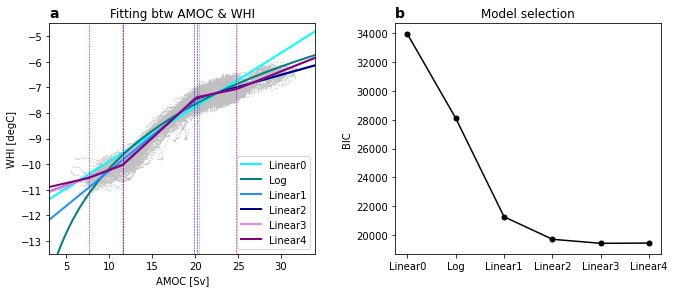

In [33]:
fig,axs = plt.subplots(1,2,figsize=(10,4)) 
plt.subplots_adjust(top=0.9,bottom=0.1,left=0.1,right=0.95,wspace=0.3)

axs[0].set_title('a',loc='left',fontdict={'weight': 'bold', 'size': 14})
axs[0].set_title('Fitting btw AMOC & WHI')
axs[0].scatter(x,y,s=0.1,c='silver',edgecolor=None)

axs[0].plot(xin,xin*mod.params[1]+mod.params[0],lw=2,c='cyan',label='Linear0')
axs[0].plot(xin,np.log(xin)*mod_log.params[1]+mod_log.params[0],lw=2,c='teal',label='Log')
axs[0].plot(xin,LinearFit(xin,best1),lw=2,c='dodgerblue',label='Linear1')
axs[0].axvline(x=best1[-1],lw=0.5,linestyle='--',c='dodgerblue')

axs[0].plot(xin,LinearFit(xin,best2),lw=2,c='navy',label='Linear2')
axs[0].axvline(x=best2[-2],lw=0.5,linestyle='--',c='navy')
axs[0].axvline(x=best2[-1],lw=0.5,linestyle='--',c='navy')

axs[0].plot(xin,LinearFit(xin,best3),lw=2,c='violet',label='Linear3')
axs[0].axvline(x=best3[-2],lw=0.5,linestyle='--',c='violet')
axs[0].axvline(x=best3[-3],lw=0.5,linestyle='--',c='violet')
axs[0].axvline(x=best3[-1],lw=0.5,linestyle='--',c='violet')

axs[0].plot(xin,LinearFit(xin,best4),lw=2,c='purple',label='Linear4')
axs[0].axvline(x=best4[-2],lw=0.5,linestyle='--',c='purple')
axs[0].axvline(x=best4[-3],lw=0.5,linestyle='--',c='purple')
axs[0].axvline(x=best4[-1],lw=0.5,linestyle='--',c='purple')
axs[0].axvline(x=best4[-4],lw=0.5,linestyle='--',c='purple')

axs[0].legend(loc='lower right')
axs[0].set_ylabel('WHI [degC]')
axs[0].set_xlabel('AMOC [Sv]')
axs[0].set_xlim(3,34)
axs[0].set_ylim(-13.5,-4.5)

axs[1].set_title('b',loc='left',fontdict={'weight': 'bold', 'size': 14})
axs[1].set_title('Model selection')
axs[1].plot(['Linear0','Log','Linear1','Linear2','Linear3','Linear4'],BIC.values(),marker='o',ms=5,c='k')
axs[1].set_ylabel('BIC')

plt.savefig('/Users/yifeifan/research/pic/Fan2024NCC/SF_SivFit_Selection.png',dpi=400)
plt.show()

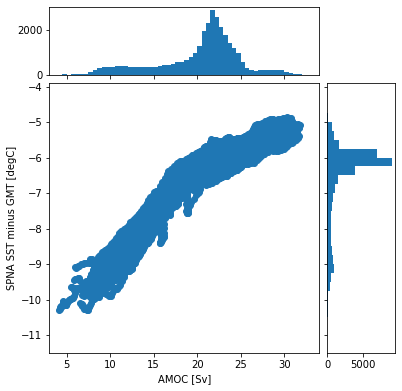

In [341]:
def scatter_hist(x, y, ax, ax_histx, ax_histy):
    # no labels
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)

    # the scatter plot:
    ax.scatter(x, y)

    # now determine nice limits by hand:
    binwidth = 0.5
    xymax = max(np.max(np.abs(x)), np.max(np.abs(y)))
    lim = (int(xymax/binwidth) + 1) * binwidth

    bins = np.arange(-lim, lim + binwidth, binwidth)
    ax_histx.hist(x, bins=bins)
    
    binwidth = 0.25
    lim = (int(xymax/binwidth) + 1) * binwidth
    bins = np.arange(-lim, lim + binwidth, binwidth)
    ax_histy.hist(y, bins=bins, orientation='horizontal')

fig = plt.figure(figsize=(6, 6))
# Add a gridspec with two rows and two columns and a ratio of 1 to 4 between
# the size of the marginal axes and the main axes in both directions.
# Also adjust the subplot parameters for a square plot.
gs = fig.add_gridspec(2, 2,  width_ratios=(4, 1), height_ratios=(1, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.05, hspace=0.05)
# Create the Axes.
ax = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)
# Draw the scatter plot and marginals.

x_seg1 = x[np.where(x<best2[-1])]
y_seg1 = y[np.where(x<best2[-1])]

x_seg2 = x[np.where(x>=best2[-1])]
y_seg2 = y[np.where(x>=best2[-1])]

scatter_hist(x, y, ax, ax_histx, ax_histy)
ax.set_xlim(3,34)
ax.set_ylim(-11.5,-3.9)
ax.set_ylabel('SPNA SST minus GMT [degC]')
ax.set_xlabel('AMOC [Sv]')
plt.show()